# Quantium Virtual Internship - Retail Strategy and Analytics - Task 1

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Customers Dataset

In [2]:
df_customers = pd.read_csv("QVI_purchase_behaviour.csv")
df_customers

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream
...,...,...,...
72632,2370651,MIDAGE SINGLES/COUPLES,Mainstream
72633,2370701,YOUNG FAMILIES,Mainstream
72634,2370751,YOUNG FAMILIES,Premium
72635,2370961,OLDER FAMILIES,Budget


# Loading Transactions Dataset

In [3]:
df_transactions = pd.read_excel("QVI_transaction_data.xlsx")
df_transactions

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
...,...,...,...,...,...,...,...,...
264831,43533,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,43325,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,43410,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,43461,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


# Renaming and Reordering Columns

In [4]:
# Renamed the column names to meaningful and business-friendly names
df_customers = df_customers.rename(columns = {"LYLTY_CARD_NBR" : "loyalty_card_number", \
                                              "LIFESTAGE" : "life_stage", \
                                              "PREMIUM_CUSTOMER" : "spending_segment"})

df_customers

,loyalty_card_number,life_stage,spending_segment
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream
...,...,...,...
72632,2370651,MIDAGE SINGLES/COUPLES,Mainstream
72633,2370701,YOUNG FAMILIES,Mainstream
72634,2370751,YOUNG FAMILIES,Premium
72635,2370961,OLDER FAMILIES,Budget


In [5]:
df_transactions = df_transactions.rename(columns = {"TXN_ID": "transaction_id", \
                                                    "DATE" : "date", \
                                                    "LYLTY_CARD_NBR" : "loyalty_card_number", \
                                                    "STORE_NBR" : "store_number", \
                                                    "PROD_NBR" : "product_number", \
                                                    "PROD_NAME" : "product_name", \
                                                    "PROD_QTY" : "quantity", \
                                                    "TOT_SALES" : "sales"} )

df_transactions

,date,store_number,loyalty_card_number,transaction_id,product_number,product_name,quantity,sales
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
...,...,...,...,...,...,...,...,...
264831,43533,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,43325,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,43410,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,43461,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


In [6]:
# Reordered the columns
df_transactions = df_transactions[["transaction_id","date","loyalty_card_number","store_number",\
                      "product_number","product_name","quantity","sales"]]
df_transactions

,transaction_id,date,loyalty_card_number,store_number,product_number,product_name,quantity,sales
0,1,43390,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,348,43599,1307,1,66,CCs Nacho Cheese 175g,3,6.3
2,383,43605,1343,1,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,974,43329,2373,2,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,1038,43330,2426,2,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
...,...,...,...,...,...,...,...,...
264831,270088,43533,272319,272,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,270154,43325,272358,272,74,Tostitos Splash Of Lime 175g,1,4.4
264833,270187,43410,272379,272,51,Doritos Mexicana 170g,2,8.8
264834,270188,43461,272379,272,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


# Datatype Inspection

In [7]:
print(df_customers.dtypes)
print("=" * 50)
print(df_transactions.dtypes)

loyalty_card_number    int64
life_stage               str
spending_segment         str
dtype: object
transaction_id           int64
date                     int64
loyalty_card_number      int64
store_number             int64
product_number           int64
product_name               str
quantity                 int64
sales                  float64
dtype: object


In [8]:
df_transactions['date'] = pd.to_datetime(df_transactions['date'], unit = 'D', origin = '1899-12-30')

# Missing Value Check

In [9]:
print(df_customers.isnull().sum())
print("=" * 30)
print(df_transactions.isnull().sum())

loyalty_card_number    0
life_stage             0
spending_segment       0
dtype: int64
transaction_id         0
date                   0
loyalty_card_number    0
store_number           0
product_number         0
product_name           0
quantity               0
sales                  0
dtype: int64


# Descriptive Statistical Analysis

In [10]:
print(df_customers.describe(include = "all"))
print("=" * 100)
print(df_transactions.describe(include = "all"))

        loyalty_card_number life_stage spending_segment
count          7.263700e+04      72637            72637
unique                  NaN          7                3
top                     NaN   RETIREES       Mainstream
freq                    NaN      14805            29245
mean           1.361859e+05        NaN              NaN
std            8.989293e+04        NaN              NaN
min            1.000000e+03        NaN              NaN
25%            6.620200e+04        NaN              NaN
50%            1.340400e+05        NaN              NaN
75%            2.033750e+05        NaN              NaN
max            2.373711e+06        NaN              NaN
        transaction_id                 date  loyalty_card_number  \
count     2.648360e+05               264836         2.648360e+05   
unique             NaN                  NaN                  NaN   
top                NaN                  NaN                  NaN   
freq               NaN                  NaN             

# Data Validation, Exploration, and Cleaning

In [11]:
# Check for duplicates
print(df_customers.duplicated().sum())
print(df_transactions.duplicated().sum())

0
1


In [12]:
# Remove Duplicates
df_transactions.drop_duplicates(inplace = True)

In [13]:
df_customers

,loyalty_card_number,life_stage,spending_segment
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream
...,...,...,...
72632,2370651,MIDAGE SINGLES/COUPLES,Mainstream
72633,2370701,YOUNG FAMILIES,Mainstream
72634,2370751,YOUNG FAMILIES,Premium
72635,2370961,OLDER FAMILIES,Budget


In [14]:
# Check for Nr_of distinct values in the loyalty_card_number column
df_customers["loyalty_card_number"].nunique()
# So, this is the primary key for the customers table

72637

In [15]:
# Check for distinct values in life_stage column
df_customers['life_stage'].unique()

<StringArray>
[ 'YOUNG SINGLES/COUPLES',         'YOUNG FAMILIES',  'OLDER SINGLES/COUPLES',
 'MIDAGE SINGLES/COUPLES',           'NEW FAMILIES',         'OLDER FAMILIES',
               'RETIREES']
Length: 7, dtype: str


###   	Life Stage			 -        Meaning
##### YOUNG SINGLES/COUPLES	 -	Young adults without children.
##### MIDAGE SINGLES/COUPLES	 -	Middle-aged adults without children.
##### NEW FAMILIES			 -  Families with very young children.
##### YOUNG FAMILIES			 -  Families with school-age children.
##### OLDER FAMILIES			 -  Families whose children are older or nearly independent.
##### OLDER SINGLES/COUPLES	 -	Older adults without dependent children.
##### RETIREES			     -  Customers who have retired from work.


In [16]:
# Check for distinct values in spending_segment column
df_customers['spending_segment'].unique()

<StringArray>
['Premium', 'Mainstream', 'Budget']
Length: 3, dtype: str


##    Spending Segment			-		Meaning
#####   	Budget			-       Customers who usually prefer lower-priced products and focus on saving money.
#####	Mainstream		-       Average customers with balanced purchasing behavior.
#####	Premium			-       Customers who are willing to spend more on higher-quality or premium brands.

In [17]:
df_transactions

,transaction_id,date,loyalty_card_number,store_number,product_number,product_name,quantity,sales
0,1,2018-10-17,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,348,2019-05-14,1307,1,66,CCs Nacho Cheese 175g,3,6.3
2,383,2019-05-20,1343,1,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,974,2018-08-17,2373,2,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,1038,2018-08-18,2426,2,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
...,...,...,...,...,...,...,...,...
264831,270088,2019-03-09,272319,272,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,270154,2018-08-13,272358,272,74,Tostitos Splash Of Lime 175g,1,4.4
264833,270187,2018-11-06,272379,272,51,Doritos Mexicana 170g,2,8.8
264834,270188,2018-12-27,272379,272,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


In [18]:
df_transactions["transaction_id"].nunique() # Returns 263127 which is not equal to 264836(Nr_of_rows). So, duplicates exist
df_transactions["transaction_id"].duplicated().sum() # Returns Nr_of duplicates over the transaction_id column
df_transactions[df_transactions["transaction_id"].duplicated()].sort_values("transaction_id") # Returns duplicate values and sorts them
df_transactions[df_transactions["transaction_id"] == 628] # So, transaction_id is not a primary key
# One transaction means one product bought by a customer. If two products bought (by the same customer or on same date), then two transactions

,transaction_id,date,loyalty_card_number,store_number,product_number,product_name,quantity,sales
228855,628,2018-12-20,2034,2,95,Sunbites Whlegrn Crisps Frch/Onin 90g,1,1.7
228856,628,2018-12-20,2034,2,104,Infuzions Thai SweetChili PotatoMix 110g,1,3.8


In [19]:
# Date range exploration
print("First transaction date is", df_transactions['date'].min())
print("Last transaction date is", df_transactions['date'].max())
print("Data range is", df_transactions['date'].max() - df_transactions['date'].min())

First transaction date is 2018-07-01 00:00:00
Last transaction date is 2019-06-30 00:00:00
Data range is 364 days 00:00:00


In [20]:
# Check for Nr_of distinct values in the loyalty_card_number column
df_transactions["loyalty_card_number"].nunique()
# So, this is the foreign key that can establish relationship with the df_customers
# Since both df_customers and df_transactions have the same Nr_of distinct values for loyalty_card_number column(i.e.,72637), so
#         all customers likely to be done the transactions and have the loyalty_card_number

72637

In [21]:
# Check for Nr_of stores
df_transactions["store_number"].nunique()

272

In [22]:
# Check for Nr_of products
df_transactions["product_number"].nunique()

114

In [23]:
# Check for Nr_of distinct values in the product_name column
df_transactions["product_name"].nunique()
# So, it is likely that each product has the product number

114

In [24]:
# Explore the quantity column
print("Minimum quantiy is",df_transactions["quantity"].min())
print("Maximum quantiy is",df_transactions["quantity"].max())
print("Average of quantiy is",df_transactions["quantity"].mean())
print("Median of quantiy is",df_transactions["quantity"].median())
# So, very few transactions have the largest quantity

Minimum quantiy is 1
Maximum quantiy is 200
Average of quantiy is 1.9073083240508242
Median of quantiy is 2.0


In [25]:
# Explore the sales column
print("Minimum sales is",df_transactions["sales"].min())
print("Maximum sales is",df_transactions["sales"].max())
print("Average of sales is",df_transactions["sales"].mean())
print("Medain of sales is",df_transactions["sales"].median())
print("Standard deviation of sales is",df_transactions["sales"].std()) # std is sensitive to outliers
# So, very few transactions have the highest sales

Minimum sales is 1.5
Maximum sales is 650.0
Average of sales is 7.304204504691601
Medain of sales is 7.4
Standard deviation of sales is 3.083230525731604


# Feature Engineering

In [26]:
# Extracting new feature pack_size_in_gms from the existing feature product_name
df_transactions["pack_size_in_gms"] = df_transactions["product_name"].str.extract(r"(\d+)")

# Changing the datatype of pack_size_in_gms from str to int
df_transactions["pack_size_in_gms"] = df_transactions["pack_size_in_gms"].astype('int')

# Exploring the column pack_size_in_gms
print(df_transactions["pack_size_in_gms"].unique())
print("Minimum pack_size_in_gms is :", df_transactions["pack_size_in_gms"].min())
print("Maximum pack_size_in_gms is :", df_transactions["pack_size_in_gms"].max())
print("Average pack_size_in_gms is :", df_transactions["pack_size_in_gms"].mean())
print("Median pack_size_in_gms is :", df_transactions["pack_size_in_gms"].median())
print("Standard Deviation of pack_size_in_gms is :", df_transactions["pack_size_in_gms"].std())

# Removes pack size from product_name and then remove leading and traling spaces
df_transactions["product_without_pack"] = df_transactions["product_name"].str.replace(r"(\d+[gG])","", regex = True).str.strip()

[175 170 150 300 330 210 270 220 125 110 134 380 180 165 135 250 200 160
 190  90  70]
Minimum pack_size_in_gms is : 70
Maximum pack_size_in_gms is : 380
Average pack_size_in_gms is : 182.42703192553853
Median pack_size_in_gms is : 170.0
Standard Deviation of pack_size_in_gms is : 64.32731628104878


In [27]:
# Extract new feature product_brand from product_without_pack

def extract_brand(product):

    if product.startswith("Red Rock Deli"):
        return "Red Rock Deli"

    elif product.startswith("Old El Paso"):
        return "Old El Paso"

    elif product.startswith("Natural Chip Co"):
        return "Natural Chip Co"

    elif product.startswith("Natural ChipCo"):
        return "Natural Chip Co"

    elif product.startswith("Natural Chip"):
        return "Natural Chip Co"

    elif product.startswith("Grain Waves"):
        return "Grain Waves"

    elif product.startswith("French Fries"):
        return "French Fries"

    elif product.startswith("Burger Rings"):
        return "Burger Rings"

    elif product.startswith("RRD"):
        return "Red Rock Deli"

    elif product.startswith("WW"):
        return "Woolworths"

    elif product.startswith("GrnWves"):
        return "Grain Waves"

    elif product.startswith("Snbts"):
        return "Sunbites"

    elif product.startswith("Infzns"):
        return "Infuzions"

    elif product.startswith("NCC"):
        return "Natural Chip Co"

    elif product.startswith("Smith "):
        return "Smiths"

    elif product.startswith("Dorito "):
        return "Doritos"

    else:
        return product.split()[0]


df_transactions["product_brand"] = (
    df_transactions["product_without_pack"]
    .apply(extract_brand)
)


# Remove brand name from product_without_pack
def remove_brand(product):

    if product.startswith("Red Rock Deli"):
        return product.replace("Red Rock Deli", "", 1).strip()

    elif product.startswith("Old El Paso"):
        return product.replace("Old El Paso", "", 1).strip()

    elif product.startswith("Natural Chip Co"):
        return product.replace("Natural Chip Co", "", 1).strip()

    elif product.startswith("Natural ChipCo"):
        return product.replace("Natural ChipCo", "", 1).strip()

    elif product.startswith("Natural Chip"):
        return product.replace("Natural Chip", "", 1).strip()

    elif product.startswith("Grain Waves"):
        return product.replace("Grain Waves", "", 1).strip()

    elif product.startswith("French Fries"):
        return product.replace("French Fries", "", 1).strip()

    elif product.startswith("Burger Rings"):
        return product.replace("Burger Rings", "", 1).strip()

    else:
        return product.split(" ", 1)[1] if " " in product else ""


df_transactions["product"] = (
    df_transactions["product_without_pack"]
    .apply(remove_brand)
)

# Remove the product_name and product_without_pack columns as they are derived into 3 columns(product_brand, product, pack_size_in_gms)
df_transactions.drop(columns = ["product_name", "product_without_pack"])

# Again Reordering the columns
df_transactions = df_transactions[["transaction_id","date","loyalty_card_number","store_number","product_number","product", \
    "product_brand","pack_size_in_gms","quantity","sales"]]

# Distinct product_brand values
df_transactions["product_brand"].unique()

<StringArray>
['Natural Chip Co',             'CCs',          'Smiths',          'Kettle',
     'Old El Paso',     'Grain Waves',         'Doritos',        'Twisties',
      'Woolworths',           'Thins',    'Burger Rings',        'Cheezels',
       'Infuzions',   'Red Rock Deli',        'Pringles',        'Tyrrells',
            'Cobs',    'French Fries',        'Tostitos',         'Cheetos',
        'Sunbites']
Length: 21, dtype: str

# Finding and removing outliers

In [28]:
# Detect and remove outliers from the data so that our insights won't mislead us
df_transactions

,transaction_id,date,loyalty_card_number,store_number,product_number,product,product_brand,pack_size_in_gms,quantity,sales
0,1,2018-10-17,1000,1,5,Compny SeaSalt,Natural Chip Co,175,2,6.0
1,348,2019-05-14,1307,1,66,Nacho Cheese,CCs,175,3,6.3
2,383,2019-05-20,1343,1,61,Crinkle Cut Chips Chicken,Smiths,170,2,2.9
3,974,2018-08-17,2373,2,69,Chip Thinly S/Cream&Onion,Smiths,175,5,15.0
4,1038,2018-08-18,2426,2,108,Tortilla ChpsHny&Jlpno Chili,Kettle,150,3,13.8
...,...,...,...,...,...,...,...,...,...,...
264831,270088,2019-03-09,272319,272,89,Sweet Chilli And Sour Cream,Kettle,175,2,10.8
264832,270154,2018-08-13,272358,272,74,Splash Of Lime,Tostitos,175,1,4.4
264833,270187,2018-11-06,272379,272,51,Mexicana,Doritos,170,2,8.8
264834,270188,2018-12-27,272379,272,42,Corn Chip Mexican Jalapeno,Doritos,150,2,7.8


Text(0, 0.5, 'Quantity')

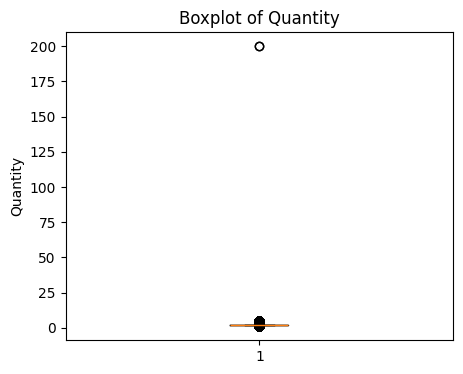

In [29]:
plt.figure(figsize=(5, 4))
plt.boxplot(df_transactions["quantity"])
plt.title("Boxplot of Quantity")
plt.ylabel("Quantity")

In [30]:
df_transactions[df_transactions["quantity"] >= 10]

,transaction_id,date,loyalty_card_number,store_number,product_number,product,product_brand,pack_size_in_gms,quantity,sales
69762,226201,2018-08-19,226000,226,4,Corn Chp Supreme,Doritos,380,200,650.0
69763,226210,2019-05-20,226000,226,4,Corn Chp Supreme,Doritos,380,200,650.0


Text(0, 0.5, 'Sales')

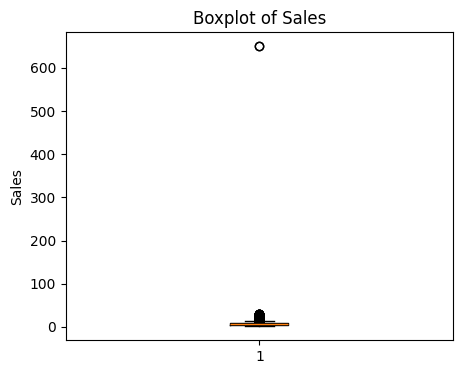

In [31]:
plt.figure(figsize=(5, 4))
plt.boxplot(df_transactions["sales"])
plt.title("Boxplot of Sales")
plt.ylabel("Sales")

In [32]:
df_transactions[df_transactions["sales"] >= 50]

,transaction_id,date,loyalty_card_number,store_number,product_number,product,product_brand,pack_size_in_gms,quantity,sales
69762,226201,2018-08-19,226000,226,4,Corn Chp Supreme,Doritos,380,200,650.0
69763,226210,2019-05-20,226000,226,4,Corn Chp Supreme,Doritos,380,200,650.0


In [33]:
# Identified two transactions with a quantity of 200 and sales of 650. These transactions are not representative of typical customer purchasing 
#        behaviour and would disproportionately influence summary statistics and customer segment analysis. Since the objective of the project is 
#        to analyze customer purchasing behaviour, these records were treated as business anomalies and removed from the dataset.
df_transactions = df_transactions[df_transactions["quantity"] != 200]

In [34]:
# Explore the quantity column
print("Minimum quantiy is",df_transactions["quantity"].min())
print("Maximum quantiy is",df_transactions["quantity"].max())
print("Average of quantiy is",df_transactions["quantity"].mean())
print("Medain of quantiy is",df_transactions["quantity"].median())
print("Standard deviation of quantiy is",df_transactions["quantity"].std())

Minimum quantiy is 1
Maximum quantiy is 5
Average of quantiy is 1.9058123421174853
Medain of quantiy is 2.0
Standard deviation of quantiy is 0.34343656379941184


In [35]:
# Explore the sales column
print("Minimum sales is",df_transactions["sales"].min())
print("Maximum sales is",df_transactions["sales"].max())
print("Average of sales is",df_transactions["sales"].mean())
print("Medain of sales is",df_transactions["sales"].median())
print("Standard deviation of sales is",df_transactions["sales"].std())

Minimum sales is 1.5
Maximum sales is 29.5
Average of sales is 7.299350911706623
Medain of sales is 7.4
Standard deviation of sales is 2.52724417605108


# Data Analysis and Visualization

###  1) Customer Segment Analysis

In [36]:
# Ensure your merged dataframe is ready
df = pd.merge(df_transactions, df_customers, on='loyalty_card_number', how='left')

# Set up a clean plotting style
sns.set_theme(style="white")

#### Business Question:
##### Which customer life stages generate the highest sales, and how does their contribution differ?

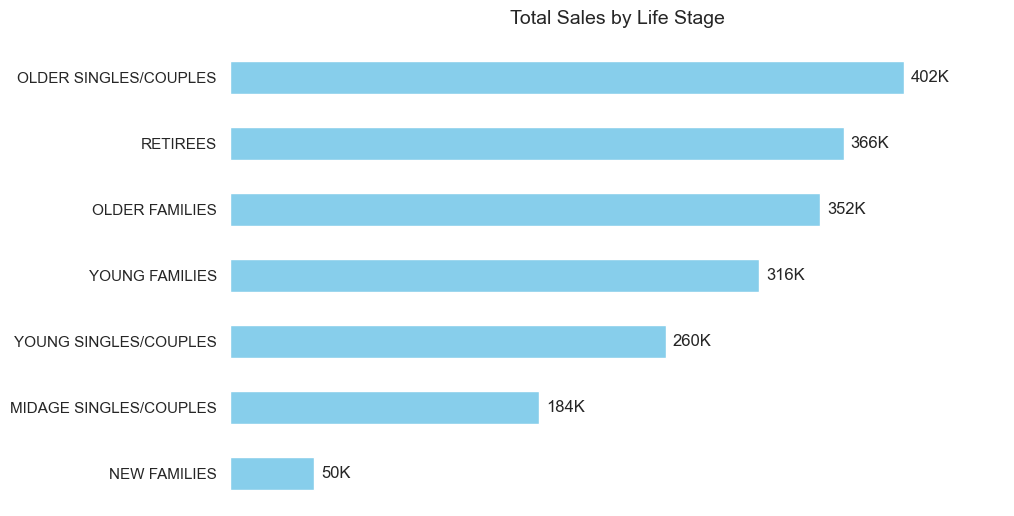

In [37]:
# Group and sort
life_stage_sales = df.groupby("life_stage")["sales"].sum().sort_values(ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
life_stage_sales.plot(kind='barh', color='skyblue', ax=ax)

# Add custom 'K' labels
labels = [f'{int(val / 1000)}K' for val in ax.containers[0].datavalues]
ax.bar_label(ax.containers[0], labels=labels, padding=5)

# Clean up axes and spines
plt.xticks([])
ax.set_ylabel("")
ax.set_xlabel("")
for spine in ax.spines.values():
    spine.set_visible(False)

plt.title("Total Sales by Life Stage", fontsize=14, pad=15)
plt.xlim(0, life_stage_sales.max() * 1.15)
plt.show()

#### Business Question:
##### How does sales performance vary across different customer spending segments?

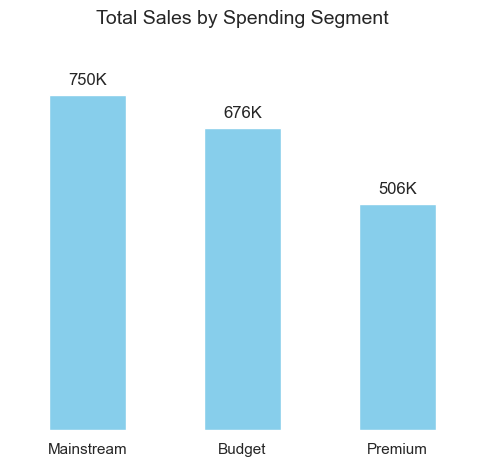

In [38]:
# Group and sort
spending_segment_sales = df.groupby("spending_segment")["sales"].sum().sort_values(ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
spending_segment_sales.plot(kind='bar', color='skyblue', ax=ax)

# Add custom 'K' labels
labels = [f'{int(val / 1000)}K' for val in ax.containers[0].datavalues]
ax.bar_label(ax.containers[0], labels=labels, padding=5)

# Clean up axes and spines
plt.yticks([])
plt.xticks(rotation=0)
ax.set_xlabel("")
ax.set_ylabel("")
for spine in ax.spines.values():
    spine.set_visible(False)

plt.title("Total Sales by Spending Segment", fontsize=14, pad=15)
plt.ylim(0, spending_segment_sales.max() * 1.15)
plt.show()

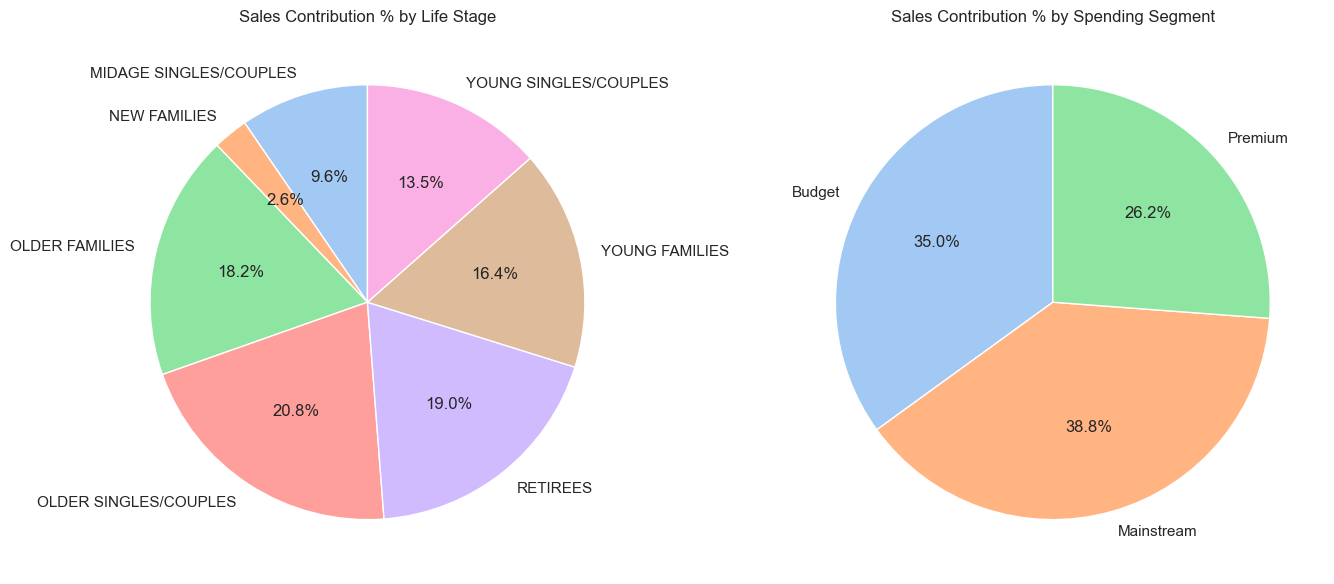

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Life Stage Contribution
df.groupby("life_stage")["sales"].sum().plot(
    kind='pie', autopct='%1.1f%%', startangle=90, 
    colors=sns.color_palette("pastel"), ax=ax1, ylabel=""
)
ax1.set_title("Sales Contribution % by Life Stage", fontsize=12)

# Spending Segment Contribution
df.groupby("spending_segment")["sales"].sum().plot(
    kind='pie', autopct='%1.1f%%', startangle=90, 
    colors=sns.color_palette("pastel"), ax=ax2, ylabel=""
)
ax2.set_title("Sales Contribution % by Spending Segment", fontsize=12)

plt.tight_layout()
plt.show()

### 2) Product Preference Analysis

#### Business Question:
##### Which product brands are the most popular and contribute the highest sales?

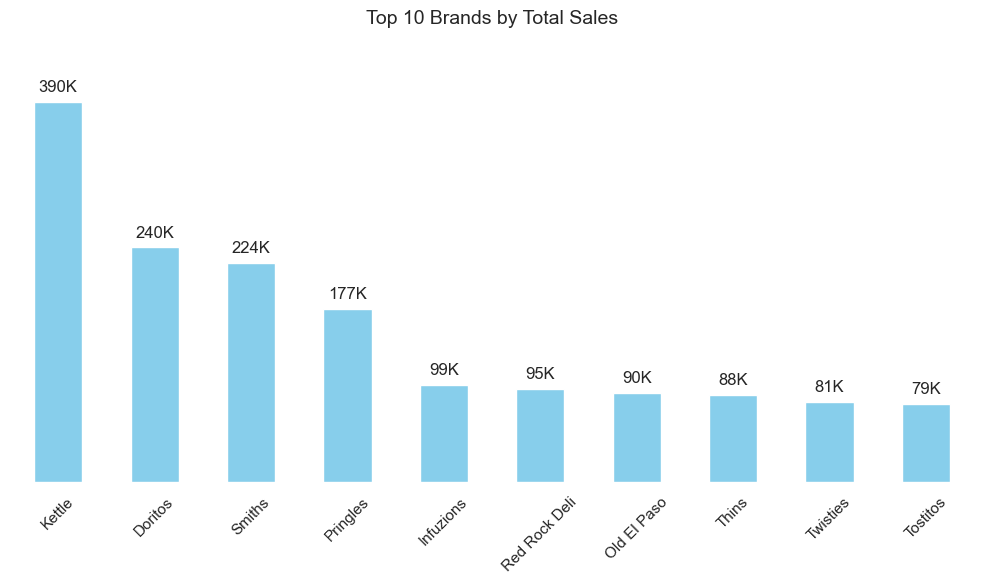

In [40]:
# 1. Calculate overall sales by brand and get the Top 10
top_brands_overall = df.groupby("product_brand")["sales"].sum().sort_values(ascending=False).head(10)

# 2. Plot as a simple, clean vertical bar chart
fig, ax = plt.subplots(figsize=(10, 6))
top_brands_overall.plot(kind='bar', color='skyblue', ax=ax)

# 3. Add custom 'K' labels on top of each bar
labels = [f'{int(val / 1000)}K' for val in ax.containers[0].datavalues]
ax.bar_label(ax.containers[0], labels=labels, padding=5)

# 4. Clean up axes and remove spines
plt.yticks([])
plt.xticks(rotation=45)
ax.set_xlabel("")
ax.set_ylabel("")
for spine in ax.spines.values():
    spine.set_visible(False)

# 5. Add title and render
plt.title("Top 10 Brands by Total Sales", fontsize=14, pad=15)
plt.ylim(0, top_brands_overall.max() * 1.15)
plt.tight_layout()
plt.show()

#### Business Question:
##### Which product are the most popular and contribute the highest sales?

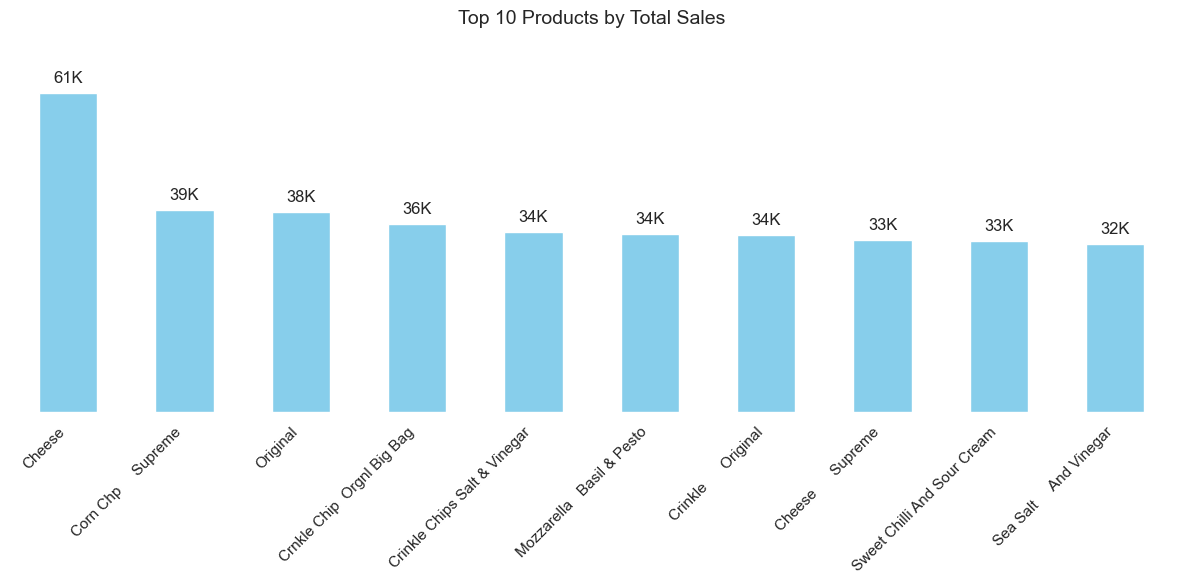

In [41]:
# 1. Group by the original product column and sum the sales to find the top 10
top_products_overall = df.groupby("product")["sales"].sum().sort_values(ascending=False).head(10)

# 2. Plot as a clean, simple vertical bar chart
fig, ax = plt.subplots(figsize=(12, 6))
top_products_overall.plot(kind='bar', color='skyblue', ax=ax)

# 3. Add custom 'K' labels on top of each bar
labels = [f'{int(val / 1000)}K' for val in ax.containers[0].datavalues]
ax.bar_label(ax.containers[0], labels=labels, padding=5)

# 4. Clean up axes and remove spines
plt.yticks([])
plt.xticks(rotation=45, ha='right')  # Rotates and aligns long product names neatly
ax.set_xlabel("")
ax.set_ylabel("")
for spine in ax.spines.values():
    spine.set_visible(False)

# 5. Add title and render
plt.title("Top 10 Products by Total Sales", fontsize=14, pad=15)
plt.ylim(0, top_products_overall.max() * 1.15)
plt.tight_layout()
plt.show()

### 4) Segment Deep Dive

#### Business Question:
##### Which combination of customer life stage and spending segment contributes the most to total sales?

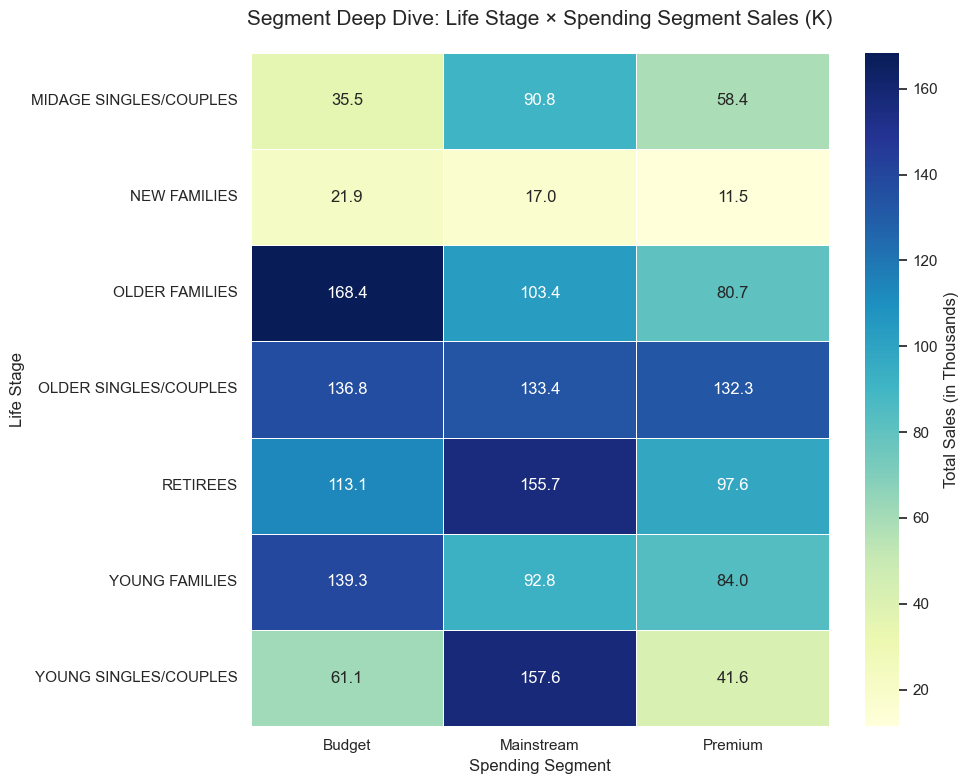

In [42]:
# Create a Pivot Table summarizing total sales
pivot_segment_sales = df.pivot_table(
    index="life_stage", 
    columns="spending_segment", 
    values="sales", 
    aggfunc="sum"
)

# Convert values to Thousands for readability
pivot_segment_sales_k = pivot_segment_sales / 1000

# Plotting the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    pivot_segment_sales_k, 
    annot=True, 
    fmt=".1f", 
    cmap="YlGnBu", 
    cbar_kws={'label': 'Total Sales (in Thousands)'},
    linewidths=0.5
)

plt.title("Segment Deep Dive: Life Stage × Spending Segment Sales (K)", fontsize=15, pad=20)
plt.ylabel("Life Stage", fontsize=12)
plt.xlabel("Spending Segment", fontsize=12)
plt.tight_layout()
plt.show()

### 5) Key Insights

##### (i) Mainstream and Budget customers contribute the highest overall sales, making them the supermarket's most valuable spending segments.
##### (ii) Older Families and Retirees generate a significant share of total revenue, indicating they are the most profitable customer groups.
##### (iii) Kettle emerged as the best-performing chip brand, suggesting strong customer preference and consistent demand.
##### (iv) The Segment Deep Dive shows that sales are concentrated in a few life stage–spending segment combinations, helping identify the supermarket's highest-value customer groups.
##### (v) Customer purchasing behavior differs across life stages and spending segments, highlighting opportunities for targeted marketing instead of generic promotions.

### 6) Business Recommendations

##### (i) Prioritize marketing campaigns for Older Families and Retirees, as these customer groups contribute the highest sales and offer the greatest revenue potential.
##### (ii) Develop targeted offers for Mainstream and Budget customers, such as loyalty rewards, personalized discounts, or bundle deals, to increase repeat purchases.
##### (iii) Maintain adequate inventory of top-selling brands like Kettle to reduce stockouts and maximize sales from products with consistently high demand.
##### (iv) Create segment-specific promotional campaigns based on customer life stage and spending behavior instead of running generic promotions. This will improve marketing efficiency and return on investment.
##### (v) Use lower-performing customer segments as opportunities for growth by introducing trial offers, cross-selling, or limited-time discounts to encourage higher purchase frequency.